In [2]:
from google.colab import drive

drive.mount('/content/drive')

%cd "/content/drive/MyDrive/1. UniMiB/Magistrale/1° Anno/Machine Learning/ML_25_26"

Mounted at /content/drive
/content/drive/MyDrive/1. UniMiB/Magistrale/1° Anno/Machine Learning/ML_25_26


In [3]:
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 742.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.4 MB/s eta 0:00:00


# Dataset Analysis

In [4]:
from ucimlrepo import fetch_ucirepo

try:
    dataset = fetch_ucirepo(id=891)
    # Create pandas DataFrame
    df = dataset.data.original
except ConnectionError as e:  # In case of ucimlrepo failure
    print(f"An error occurred while fetching the dataset: {e}")
    print("Trying with local CSV file...")

    import pandas as pd

    df = pd.read_csv("/MyDrive/1. UniMiB/Magistrale/1° Anno/Machine Learning/ML_25_26dataset/diabetes_binary_health_indicators_BRFSS2015.csv")

In [5]:
df.dtypes

,0
ID,int64
Diabetes_binary,int64
HighBP,int64
HighChol,int64
CholCheck,int64
BMI,int64
Smoker,int64
Stroke,int64
HeartDiseaseorAttack,int64
PhysActivity,int64


In [6]:
df.describe()

,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,126839.500000,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,73231.252481,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,63419.750000,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,126839.500000,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,190259.250000,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,253679.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [7]:
# Separate features and target variable
try:
    features = df.drop(columns=["ID", "Diabetes_binary"])
except Exception as e:  # In case of ucimlrepo failure
    print(f"An error occurred while dropping columns: {e}")
    features = df.drop(columns=["Diabetes_binary"])
features.dtypes

,0
HighBP,int64
HighChol,int64
CholCheck,int64
BMI,int64
Smoker,int64
Stroke,int64
HeartDiseaseorAttack,int64
PhysActivity,int64
Fruits,int64
Veggies,int64


In [8]:
# float64 In case of ucimlrepo failure, .csv data are float64
numeric_features = features.select_dtypes(["int64", "float64"]).columns
FEATURES_NUMBER = len(numeric_features)
print(numeric_features)

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


In [9]:
# Controlliamo la percentuale di 0 e 1 nel dataset originale
class_distribution = df["Diabetes_binary"].value_counts(normalize=True) * 100
print("Class Distribution:")
print(class_distribution)

Class Distribution:
Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features[numeric_features])
print(scaled_data)

[[ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
  -1.4744874 ]
 [-0.86678537 -0.85818163 -5.07816412 ... -0.33793279  0.96327159
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
   0.93963796]
 ...
 [-0.86678537 -0.85818163  0.19692156 ... -1.97501498 -0.05116153
  -1.95731247]
 [ 1.15368814 -0.85818163  0.19692156 ... -0.33793279 -0.05116153
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008  0.96327159
  -1.95731247]]


## Dataset Splitting

In [11]:
from sklearn.model_selection import train_test_split

# 1. Data Preparation
X = scaled_data
y = df["Diabetes_binary"].values

# Split in Train e Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# PCA

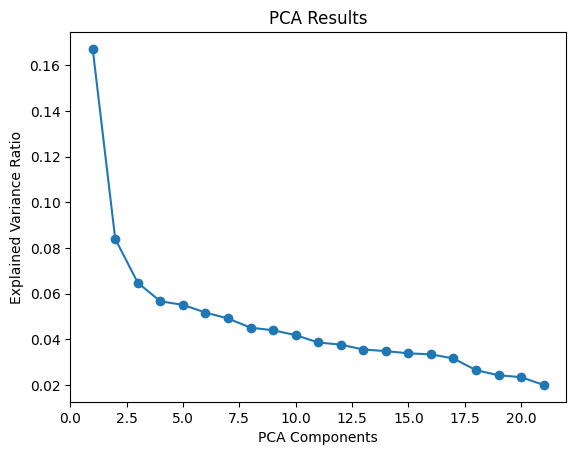

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA().fit(scaled_data)

plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_, marker="o")
plt.xlabel("PCA Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Results")
plt.show()

In [13]:
pca.explained_variance_ratio_

array([0.16713006, 0.08396704, 0.06480288, 0.05667649, 0.05512874,
       0.05176754, 0.04916833, 0.04515407, 0.04399236, 0.04190459,
       0.03864939, 0.03771927, 0.03557995, 0.03488982, 0.03391184,
       0.03346775, 0.03166342, 0.0265529 , 0.02430867, 0.02348267,
       0.02008222])

In [14]:
# Find number of components that explain at least 85% of variance
cumulative_variance = pca.explained_variance_ratio_.cumsum()
n_components = (cumulative_variance < 0.8).sum() + 1
print(f"Number of components to explain at least 80% variance: {n_components}")

Number of components to explain at least 80% variance: 14


In [15]:
pca = PCA(n_components=n_components).fit(scaled_data)
pca_data = pca.transform(scaled_data)
print(pca_data)

[[ 4.77569195 -0.43214148  0.3356638  ...  1.07069858  0.02771312
  -0.9365576 ]
 [ 0.57292634 -5.45915935 -1.55664967 ...  0.42521384  0.4095685
   1.99007186]
 [ 4.94131986 -1.79586563  2.02481371 ... -0.59093257 -1.31928458
   1.22113362]
 ...
 [-1.30555165 -1.71669629 -0.15111092 ... -1.01693462  0.00761598
   0.42516302]
 [ 0.46393464 -0.12676433 -0.14465724 ... -0.85688877 -0.6619505
  -0.30037722]
 [ 0.78648932  1.5785753  -0.31414497 ... -1.66225812  1.62052365
   0.01119061]]


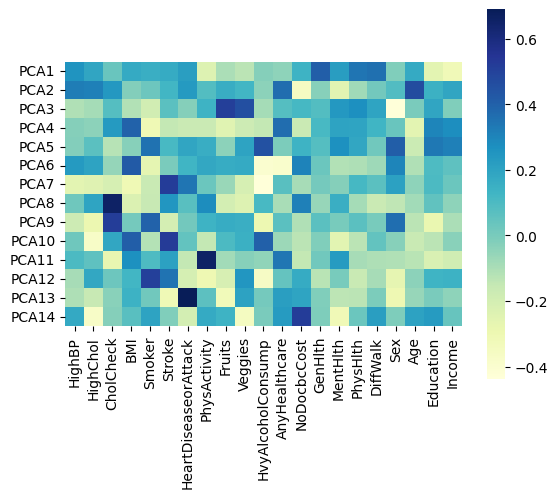

In [16]:
import seaborn as sns

ax = sns.heatmap(
    pca.components_,
    cmap="YlGnBu",
    yticklabels=["PCA" + str(x) for x in range(1, pca.n_components_ + 1)],
    xticklabels=list(numeric_features),
    cbar_kws={"orientation": "vertical"},
)
ax.set_aspect("equal")

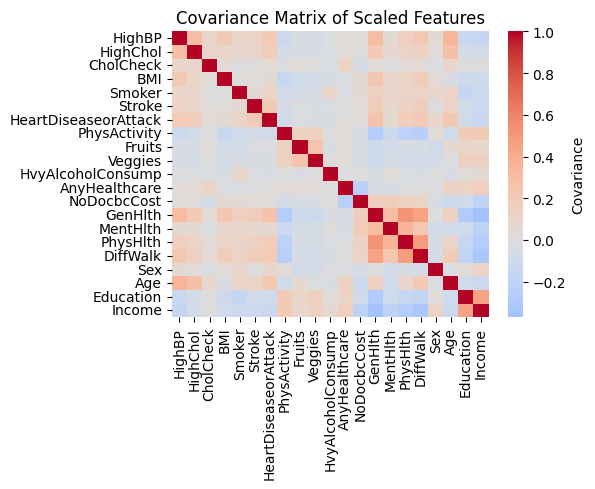

Covariance matrix shape: (21, 21)


In [17]:
import numpy as np

# Calculate covariance matrix
cov_matrix = np.cov(scaled_data.T)

# Display covariance matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cov_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    xticklabels=numeric_features,
    yticklabels=numeric_features,
    cbar_kws={"label": "Covariance"},
)
plt.title("Covariance Matrix of Scaled Features")
plt.tight_layout()
plt.show()

print(f"Covariance matrix shape: {cov_matrix.shape}")

In [18]:
# 1. Data Preparation
X_pca = pca_data
y = df["Diabetes_binary"].values

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

print(f"Dimensioni Training Set: {X_train_pca.shape}")

Dimensioni Training Set: (177576, 14)


È stato necessario selezionare parecchie componenti princiapli perchè, come si nota dalla matrice di covarianza, abbiamo in generale una bassa correlazione tra le feature.

# Neural Network

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils import class_weight
import tensorflow as tf

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc


def evaluate_and_plot(model, X_test, y_test, history, threshold=0.5, title_suffix=""):
    # Predizioni e binarizzazione
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > threshold).astype("int32")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.show()

    # Report di classificazione
    print("Report di Classificazione:")
    print(classification_report(y_test, y_pred))

    # Calcolo ROC-AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    # Curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    plt.plot(
        [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier"
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    title = "Curva ROC" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"\nAUC Score: {roc_auc:.4f}")

    # Curve di Loss e Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("loss", []), label="Train Loss")
    plt.plot(history.history.get("val_loss", []), label="Val Loss")
    plt.title("Model Loss" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
    plt.plot(history.history.get("val_accuracy", []), label="Val Accuracy")
    plt.title("Model Accuracy" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()
    plt.show()

## No PCA

### Original Features

In [21]:
# 2. Creazione del Modello
model = Sequential()

# Strati Nascosti
model.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model.add(Dense(1, activation="sigmoid"))

# 3. Compilazione
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# 4. Addestramento
history = model.fit(
    X_train, y_train, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8441 - loss: 0.3745 - val_accuracy: 0.8653 - val_loss: 0.3193
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8630 - loss: 0.3234 - val_accuracy: 0.8648 - val_loss: 0.3174
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8630 - loss: 0.3220 - val_accuracy: 0.8658 - val_loss: 0.3164
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8635 - loss: 0.3210 - val_accuracy: 0.8647 - val_loss: 0.3163
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8650 - loss: 0.3181 - val_accuracy: 0.8655 - val_loss: 0.3166
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8645 - loss: 0.3177 - val_accuracy: 0.8653 - val_loss: 0.3158
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8646 - loss: 0.3171 - val_accuracy: 0.8652 - val_loss: 0.3166
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8648 - loss: 0.3176 - val_accu

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 1s 494us/step


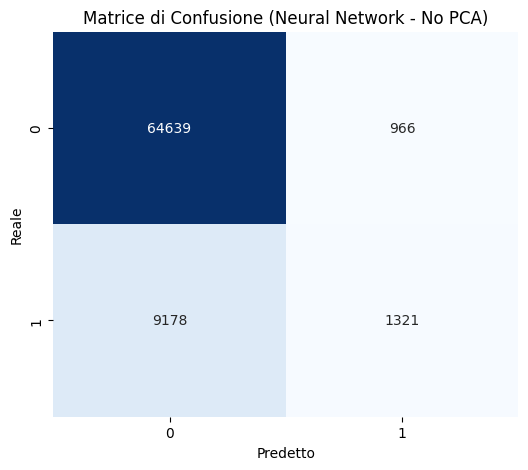

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     65605
           1       0.58      0.13      0.21     10499

    accuracy                           0.87     76104
   macro avg       0.73      0.56      0.57     76104
weighted avg       0.83      0.87      0.83     76104



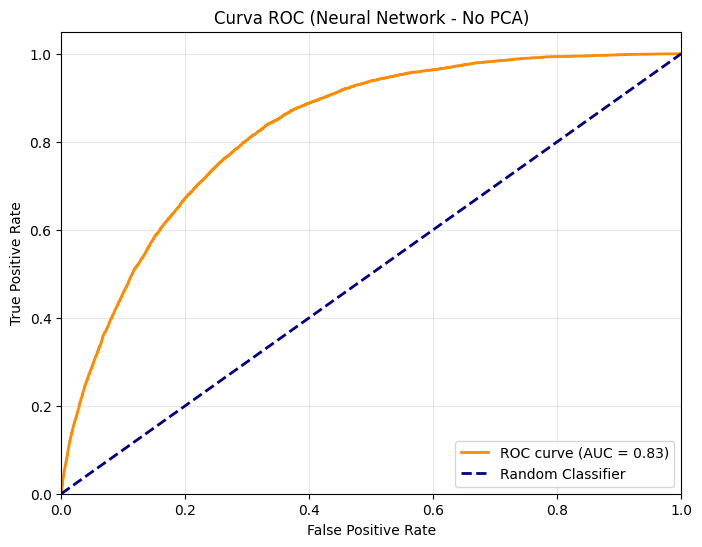


AUC Score: 0.8268


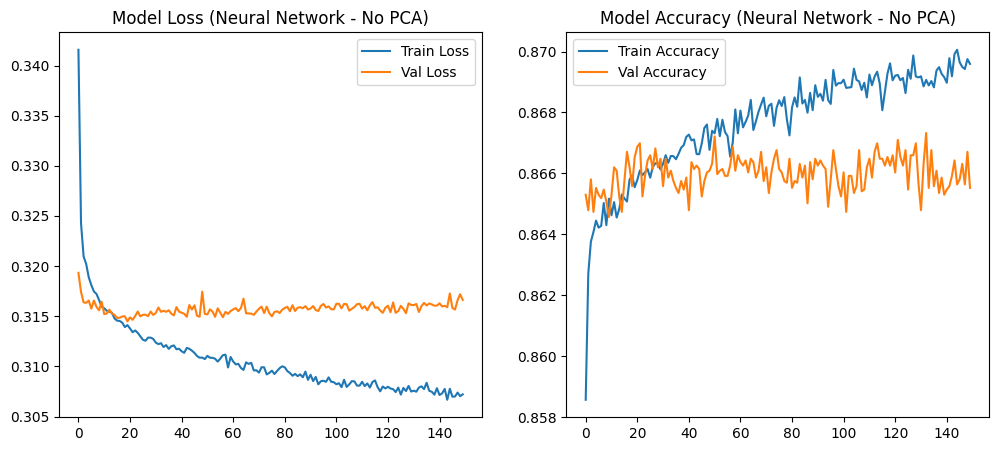

In [22]:
# 5. Valutazione
evaluate_and_plot(
    model, X_test, y_test, history, title_suffix="Neural Network - No PCA"
)

### Undersampling

Class Balancing

In [23]:
# 1. Creazione dataset bilanciato (undersampling su tutto il dataset)
idx_minority = np.where(y == 1)[0]
idx_majority = np.where(y == 0)[0]

n_minority = len(idx_minority)

idx_majority_downsampled = np.random.choice(
    idx_majority, size=n_minority, replace=False
)

idx_balanced = np.concatenate([idx_majority_downsampled, idx_minority])
np.random.shuffle(idx_balanced)

X_bal = X[idx_balanced]
y_bal = y[idx_balanced]

print("Distribuzione classi nel dataset bilanciato:")
unique, counts = np.unique(y_bal, return_counts=True)
print(dict(zip(unique, counts)))

# 2. Train/test split sul dataset bilanciato
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal
)

print("Distribuzione classi nel Training Set bilanciato:")
unique_tr, counts_tr = np.unique(y_train_bal, return_counts=True)
print(dict(zip(unique_tr, counts_tr)))

print("Distribuzione classi nel Test Set bilanciato:")
unique_te, counts_te = np.unique(y_test_bal, return_counts=True)
print(dict(zip(unique_te, counts_te)))

Distribuzione classi nel dataset bilanciato:
{np.int64(0): np.int64(35346), np.int64(1): np.int64(35346)}
Distribuzione classi nel Training Set bilanciato:
{np.int64(0): np.int64(24742), np.int64(1): np.int64(24742)}
Distribuzione classi nel Test Set bilanciato:
{np.int64(0): np.int64(10604), np.int64(1): np.int64(10604)}


In [24]:
# 3. Creazione del Modello
model_pca_under = Sequential()
model_pca_under.add(Dense(64, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_pca_under.add(Dropout(0.5))

model_pca_under.add(Dense(32, activation="relu"))
model_pca_under.add(Dropout(0.3))

model_pca_under.add(Dense(16, activation="relu"))
model_pca_under.add(Dropout(0.3))

model_pca_under.add(Dense(1, activation="sigmoid"))

model_pca_under.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 4. Addestramento
history_pca_under = model_pca_under.fit(
    X_train_bal,
    y_train_bal,
    epochs=100,
    batch_size=128,
    verbose=1,
    validation_split=0.1,
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6180 - loss: 0.6433 - val_accuracy: 0.7430 - val_loss: 0.5217
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7301 - loss: 0.5463 - val_accuracy: 0.7472 - val_loss: 0.5125
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7435 - loss: 0.5342 - val_accuracy: 0.7509 - val_loss: 0.5091
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7405 - loss: 0.5337 - val_accuracy: 0.7525 - val_loss: 0.5078
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7450 - loss: 0.5261 - val_accuracy: 0.7547 - val_loss: 0.5072
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7462 - loss: 0.5261 - val_accuracy: 0.7531 - val_loss: 0.5071
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7477 - loss: 0.5234 - val_accuracy: 0.7539 - val_loss: 0.5087
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7504 - loss: 0.5229 - val_accuracy: 0.7555

663/663 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step


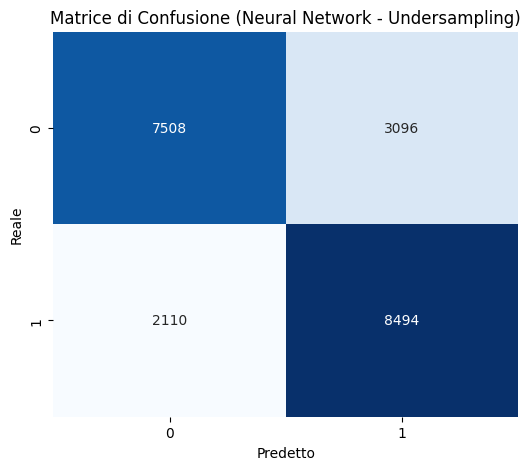

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.78      0.71      0.74     10604
           1       0.73      0.80      0.77     10604

    accuracy                           0.75     21208
   macro avg       0.76      0.75      0.75     21208
weighted avg       0.76      0.75      0.75     21208



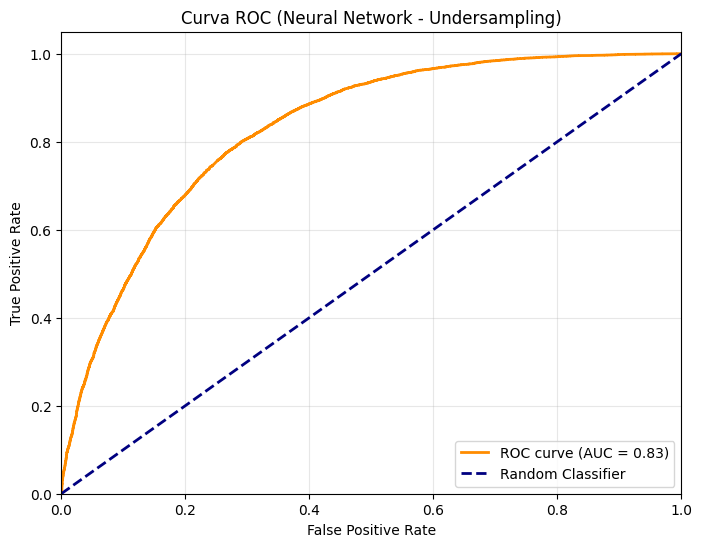


AUC Score: 0.8297


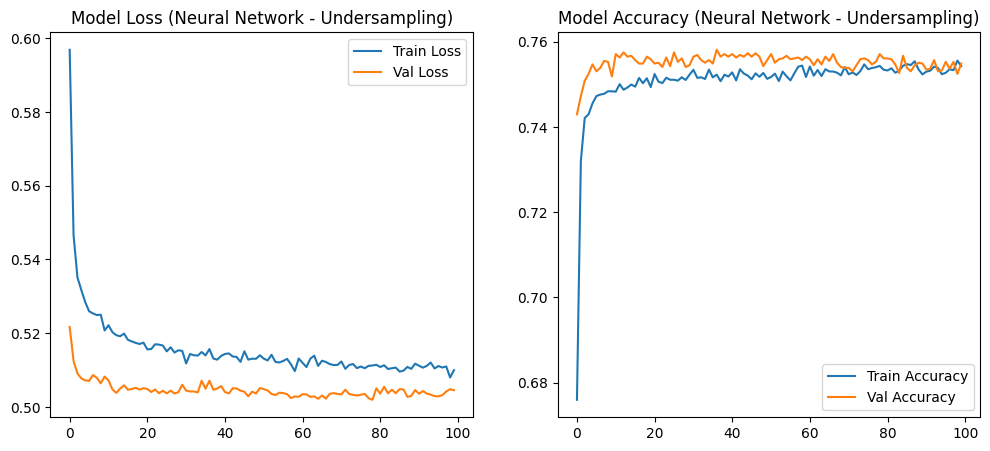

In [25]:
# 5. Valutazione
evaluate_and_plot(
    model_pca_under,
    X_test_bal,
    y_test_bal,
    history_pca_under,
    title_suffix="Neural Network - Undersampling",
)

### Class Weights

In [26]:
# 2. Calcolo dei Class Weights
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

model_no_pca_weighted = Sequential()

# Strati Nascosti
model_no_pca_weighted.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

model_no_pca_weighted.add(Dense(64, activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

model_no_pca_weighted.add(Dense(32, activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_no_pca_weighted.add(Dense(1, activation="sigmoid"))

model_no_pca_weighted.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 4. Addestramento con Class Weights
history_no_pca_weighted = model_no_pca_weighted.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6665 - loss: 0.5603 - val_accuracy: 0.6995 - val_loss: 0.5147
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6995 - loss: 0.5210 - val_accuracy: 0.7072 - val_loss: 0.4952
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7080 - loss: 0.5139 - val_accuracy: 0.7062 - val_loss: 0.5051
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7136 - loss: 0.5088 - val_accuracy: 0.7199 - val_loss: 0.4952
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7127 - loss: 0.5155 - val_accuracy: 0.7147 - val_loss: 0.4972
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7093 - loss: 0.5178 - val_accuracy: 0.7295 - val_loss: 0.4927
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7194 - loss: 0.5081 - val_accuracy: 0.7242 - val_loss: 0.5073
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7182 - loss: 0.5103 - val_accuracy: 0.7180

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 1s 493us/step


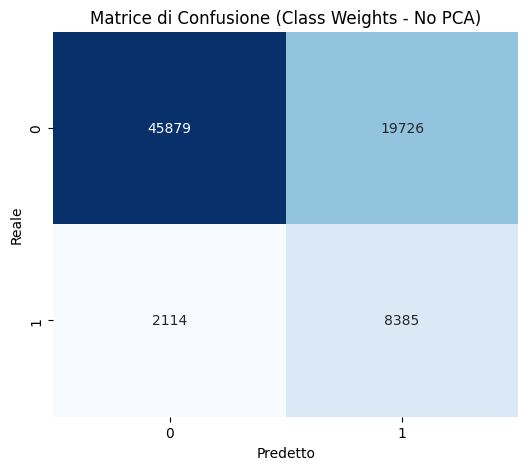

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     65605
           1       0.30      0.80      0.43     10499

    accuracy                           0.71     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.87      0.71      0.76     76104



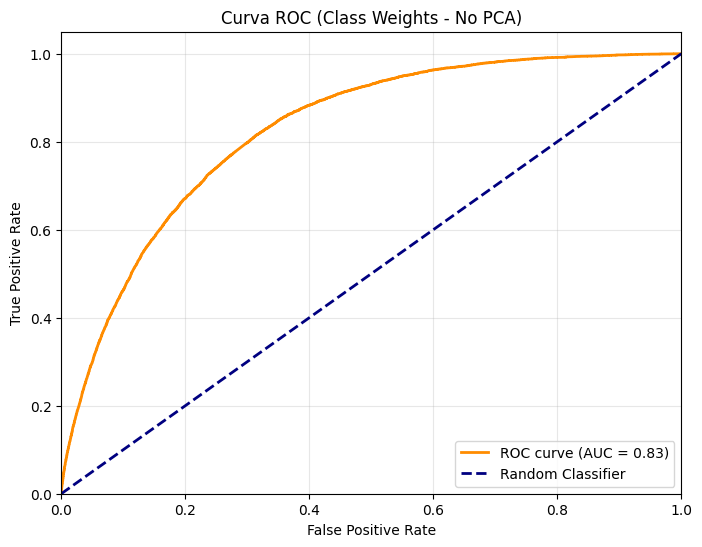


AUC Score: 0.8254


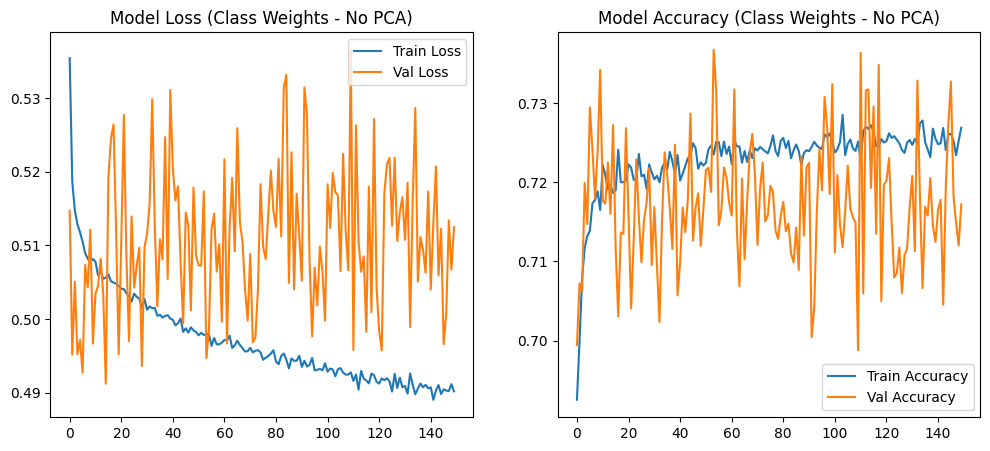

In [27]:
# 5. Valutazione
evaluate_and_plot(
    model_no_pca_weighted,
    X_test,
    y_test,
    history_no_pca_weighted,
    title_suffix="Class Weights - No PCA",
)

### Focal Loss
Va leggermente meglio (non so quanto, da analizzare...) però ha un maggior onere computazionale.
A livello di tempi Class Weights è molto più veloce.

In [28]:
# Definizione corretta della Focal Loss per classificazione binaria
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss per classificazione binaria sbilanciata.

    Parameters:
    - gamma: focusing parameter (default=2.0). Maggiore è gamma, più il modello si concentra sugli esempi difficili
    - alpha: peso per la classe positiva (default=0.25). Per dati sbilanciati, usa alpha ≈ frequenza classe negativa
    """

    def focal_loss_fixed(y_true, y_pred):
        # Converti tutto a float32 per evitare problemi di tipo
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        # Binary Cross Entropy
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)

        # Focal Loss modulation
        # Per gli esempi della classe 1 (y_true=1): p_t = y_pred
        # Per gli esempi della classe 0 (y_true=0): p_t = 1 - y_pred
        p_t = tf.where(tf.equal(y_true, 1.0), y_pred, 1 - y_pred)

        # Alpha balancing (converti alpha a float32)
        alpha_f32 = tf.constant(alpha, dtype=tf.float32)
        alpha_t = tf.where(tf.equal(y_true, 1.0), alpha_f32, 1 - alpha_f32)

        # Focal term: (1 - p_t)^gamma (converti gamma a float32)
        gamma_f32 = tf.constant(gamma, dtype=tf.float32)
        focal_weight = tf.pow(1.0 - p_t, gamma_f32)

        # Focal Loss finale
        focal_loss = alpha_t * focal_weight * bce

        return tf.reduce_mean(focal_loss)

    return focal_loss_fixed

In [29]:
# Calcola alpha ottimale basato sulla distribuzione delle classi
class_freq_np = np.bincount(y_train.astype(int))
alpha_optimal_np = float(class_freq_np[0] / (class_freq_np[0] + class_freq_np[1]))
print(f"Alpha ottimale calcolato: {alpha_optimal_np:.3f}")

# 2. Creazione del Modello
model_no_pca_focal = Sequential()

# Strati Nascosti
model_no_pca_focal.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_no_pca_focal.add(Dropout(0.3))

model_no_pca_focal.add(Dense(64, activation="relu"))
model_no_pca_focal.add(Dropout(0.3))

model_no_pca_focal.add(Dense(32, activation="relu"))
model_no_pca_focal.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_no_pca_focal.add(Dense(1, activation="sigmoid"))

# 3. Compilazione con Focal Loss
model_no_pca_focal.compile(
    loss=focal_loss(gamma=2.0, alpha=alpha_optimal_np),
    optimizer="adam",
    metrics=["accuracy"],
)

# 4. Addestramento
history_no_pca_focal = model_no_pca_focal.fit(
    X_train, y_train, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

Alpha ottimale calcolato: 0.860
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6759 - loss: 0.0348 - val_accuracy: 0.6806 - val_loss: 0.0319
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6918 - loss: 0.0321 - val_accuracy: 0.6983 - val_loss: 0.0320
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7041 - loss: 0.0318 - val_accuracy: 0.7125 - val_loss: 0.0317
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7076 - loss: 0.0319 - val_accuracy: 0.7060 - val_loss: 0.0317
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7086 - loss: 0.0317 - val_accuracy: 0.7268 - val_loss: 0.0317
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7132 - loss: 0.0317 - val_accuracy: 0.7153 - val_loss: 0.0316
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7154 - loss: 0.0314 - val_accuracy: 0.7322 - val_loss: 0.0316
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7244 - loss: 0.0314 - val_accuracy: 0.7344

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 1s 511us/step


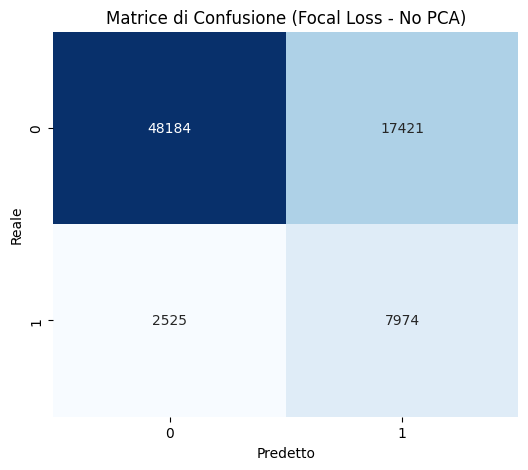

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.95      0.73      0.83     65605
           1       0.31      0.76      0.44     10499

    accuracy                           0.74     76104
   macro avg       0.63      0.75      0.64     76104
weighted avg       0.86      0.74      0.78     76104



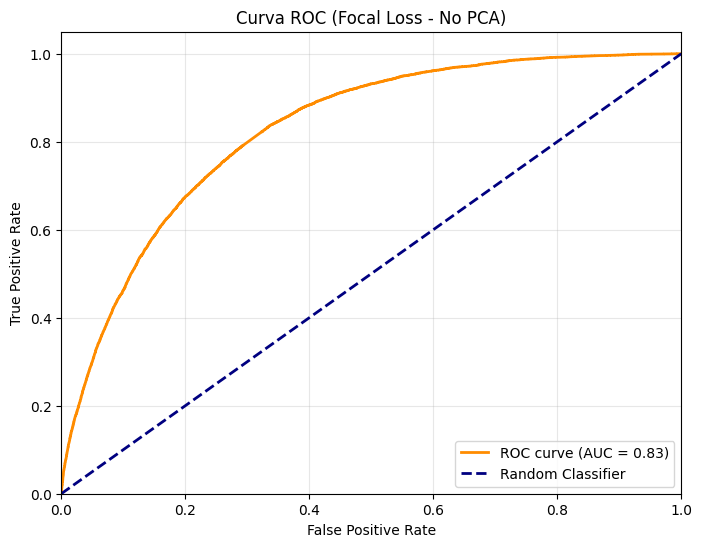


AUC Score: 0.8256


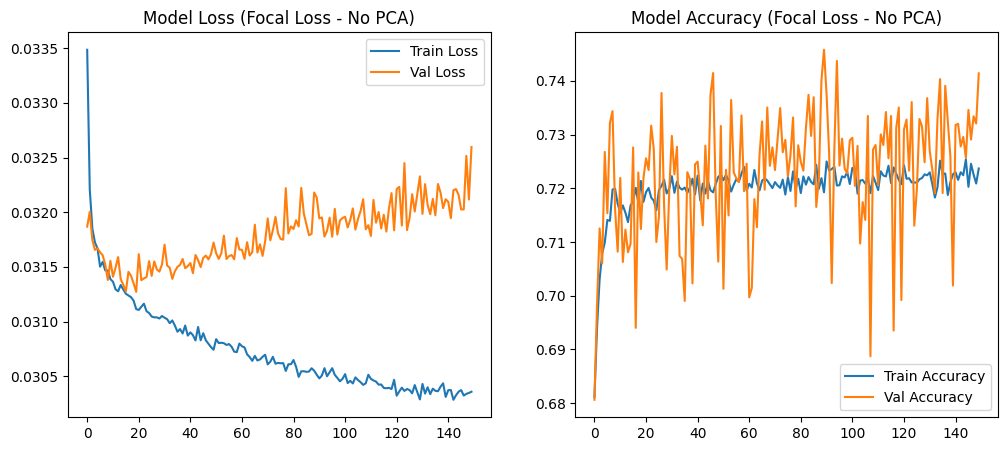

In [30]:
# 5. Valutazione
evaluate_and_plot(
    model_no_pca_focal,
    X_test,
    y_test,
    history_no_pca_focal,
    title_suffix="Focal Loss - No PCA",
)

## PCA

### Class Weights

In [31]:
# 2. Calcolo dei Class Weights
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_pca), y=y_train_pca
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

# 3. Creazione del Modello
model_pca_weighted = Sequential()
model_pca_weighted.add(Dense(32, input_shape=(n_components,), activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(16, activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(8, activation="relu"))
model_pca_weighted.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_pca_weighted.add(Dense(1, activation="sigmoid"))

model_pca_weighted.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 4. Addestramento con Class Weights
history_pca_weighted = model_pca_weighted.fit(
    X_train_pca,
    y_train_pca,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6316 - loss: 0.6375 - val_accuracy: 0.6766 - val_loss: 0.5192
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6594 - loss: 0.5580 - val_accuracy: 0.6752 - val_loss: 0.5389
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6697 - loss: 0.5522 - val_accuracy: 0.7013 - val_loss: 0.5169
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6864 - loss: 0.5396 - val_accuracy: 0.7165 - val_loss: 0.5123
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6948 - loss: 0.5409 - val_accuracy: 0.7218 - val_loss: 0.5243
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6996 - loss: 0.5390 - val_accuracy: 0.7408 - val_loss: 0.5039
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7133 - loss: 0.5359 - val_accuracy: 0.7247 - val_loss: 0.5283
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7083 - loss: 0.5337 - val_accuracy: 0.7335

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 1s 460us/step


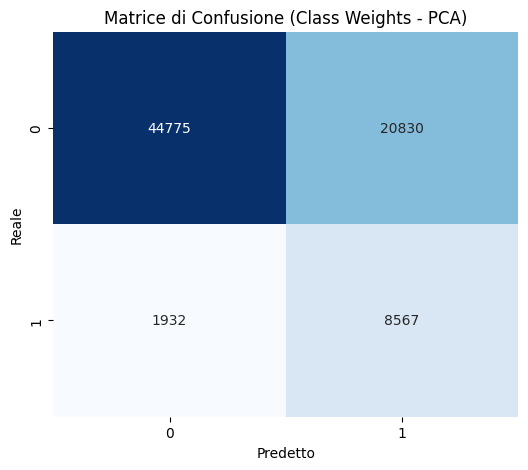

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.68      0.80     65605
           1       0.29      0.82      0.43     10499

    accuracy                           0.70     76104
   macro avg       0.63      0.75      0.61     76104
weighted avg       0.87      0.70      0.75     76104



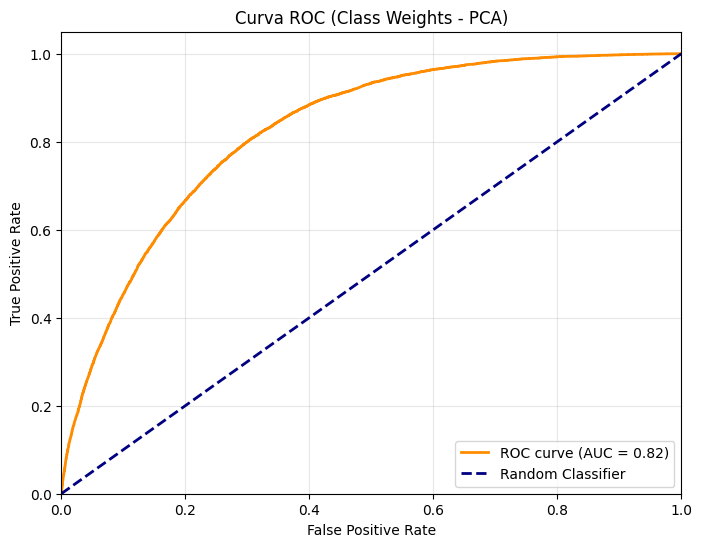


AUC Score: 0.8241


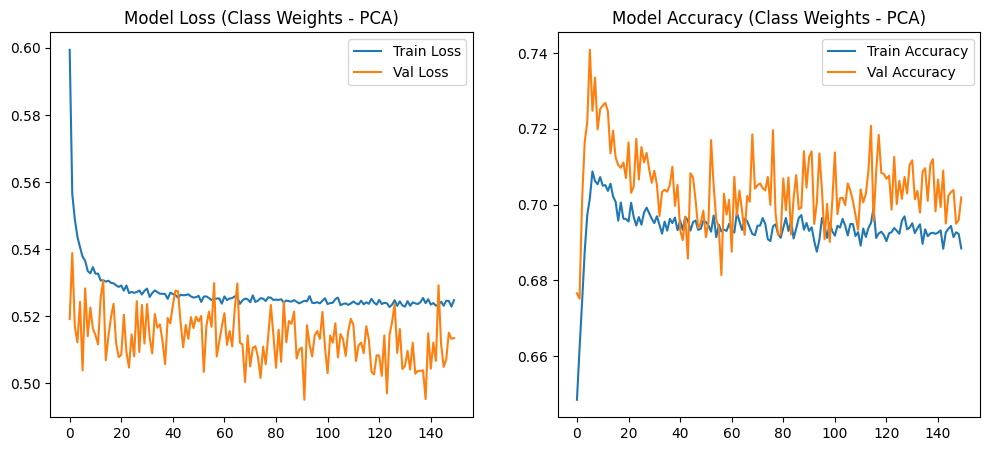

In [32]:
# 5. Valutazione
evaluate_and_plot(
    model_pca_weighted,
    X_test_pca,
    y_test_pca,
    history_pca_weighted,
    title_suffix="Class Weights - PCA",
)

### Focal Loss
Direi di togliere questa parte, non porta miglioramenti significativi.

In [33]:
# Calcola alpha ottimale basato sulla distribuzione delle classi
# alpha ≈ freq(classe 0) per dare più peso alla classe minoritaria (1)
class_freq = np.bincount(y_train_pca.astype(int))
alpha_optimal = float(class_freq[0] / (class_freq[0] + class_freq[1]))
print(f"Alpha ottimale calcolato: {alpha_optimal:.3f}")

# 2. Creazione del Modello
model_pca_focal = Sequential()

model_pca_focal.add(Dense(32, input_shape=(n_components,), activation="relu"))
model_pca_focal.add(Dropout(0.3))

model_pca_focal.add(Dense(16, activation="relu"))
model_pca_focal.add(Dropout(0.3))

model_pca_focal.add(Dense(8, activation="relu"))
model_pca_focal.add(Dropout(0.3))

model_pca_focal.add(Dense(1, activation="sigmoid"))

# 3. Compilazione con Focal Loss
# Usa gamma=2.0 e alpha calcolato automaticamente
model_pca_focal.compile(
    loss=focal_loss(gamma=2.0, alpha=alpha_optimal),
    optimizer="adam",
    metrics=["accuracy"],
)

# 4. Addestramento
history_pca_focal = model_pca_focal.fit(
    X_train_pca,
    y_train_pca,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
)

Alpha ottimale calcolato: 0.860
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5175 - loss: 0.0444 - val_accuracy: 0.7854 - val_loss: 0.0353
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7457 - loss: 0.0356 - val_accuracy: 0.7374 - val_loss: 0.0336
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7263 - loss: 0.0346 - val_accuracy: 0.7628 - val_loss: 0.0338
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7293 - loss: 0.0343 - val_accuracy: 0.7534 - val_loss: 0.0334
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7268 - loss: 0.0343 - val_accuracy: 0.7616 - val_loss: 0.0335
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7311 - loss: 0.0340 - val_accuracy: 0.7511 - val_loss: 0.0331
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7272 - loss: 0.0338 - val_accuracy: 0.7576 - val_loss: 0.0330
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7297 - loss: 0.0337 - val_accuracy: 0.7813

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 1s 479us/step


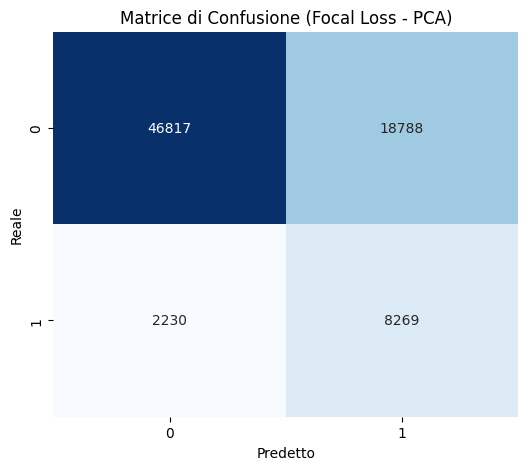

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.95      0.71      0.82     65605
           1       0.31      0.79      0.44     10499

    accuracy                           0.72     76104
   macro avg       0.63      0.75      0.63     76104
weighted avg       0.87      0.72      0.76     76104



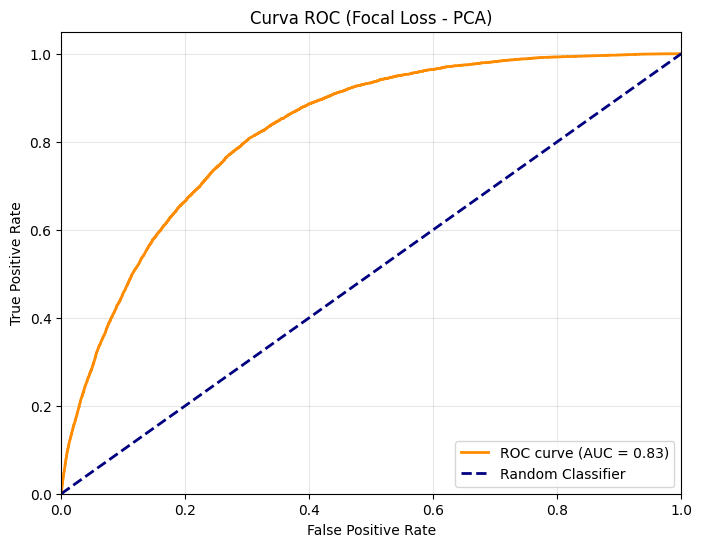


AUC Score: 0.8254


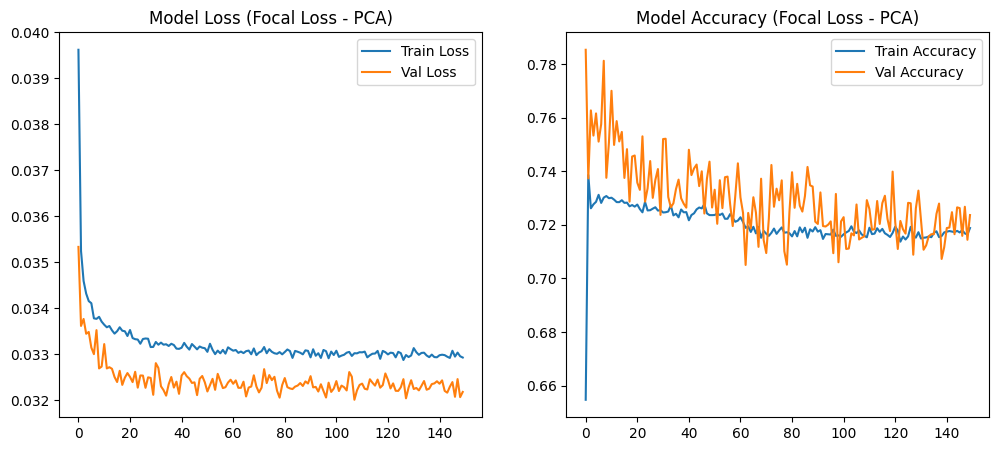

In [34]:
# 5. Valutazione
evaluate_and_plot(
    model_pca_focal,
    X_test_pca,
    y_test_pca,
    history_pca_focal,
    title_suffix="Focal Loss - PCA",
)

# Decision Tree

In [35]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import plot_tree


def show_tree_metrics(tree, y_test, y_pred):
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    if hasattr(tree, "get_depth"):
      print(f"Profondità albero: {tree.get_depth()}")
      print(f"Numero di foglie: {tree.get_n_leaves()}")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione"
    plt.title(title)
    plt.show()

    print("\n" + classification_report(y_test, y_pred))


def print_tree(tree, max_depth, title):
    plt.figure(figsize=(25, 12))
    plot_tree(
        tree,
        filled=True,
        feature_names=numeric_features,
        class_names=["0", "1"],
        fontsize=8,
        max_depth=max_depth,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

## No PCA

### No Pruning

Accuracy: 0.7980
Profondità albero: 38
Numero di foglie: 32829


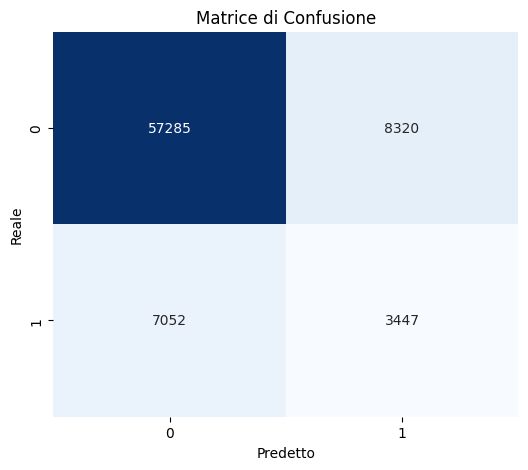


              precision    recall  f1-score   support

           0       0.89      0.87      0.88     65605
           1       0.29      0.33      0.31     10499

    accuracy                           0.80     76104
   macro avg       0.59      0.60      0.60     76104
weighted avg       0.81      0.80      0.80     76104



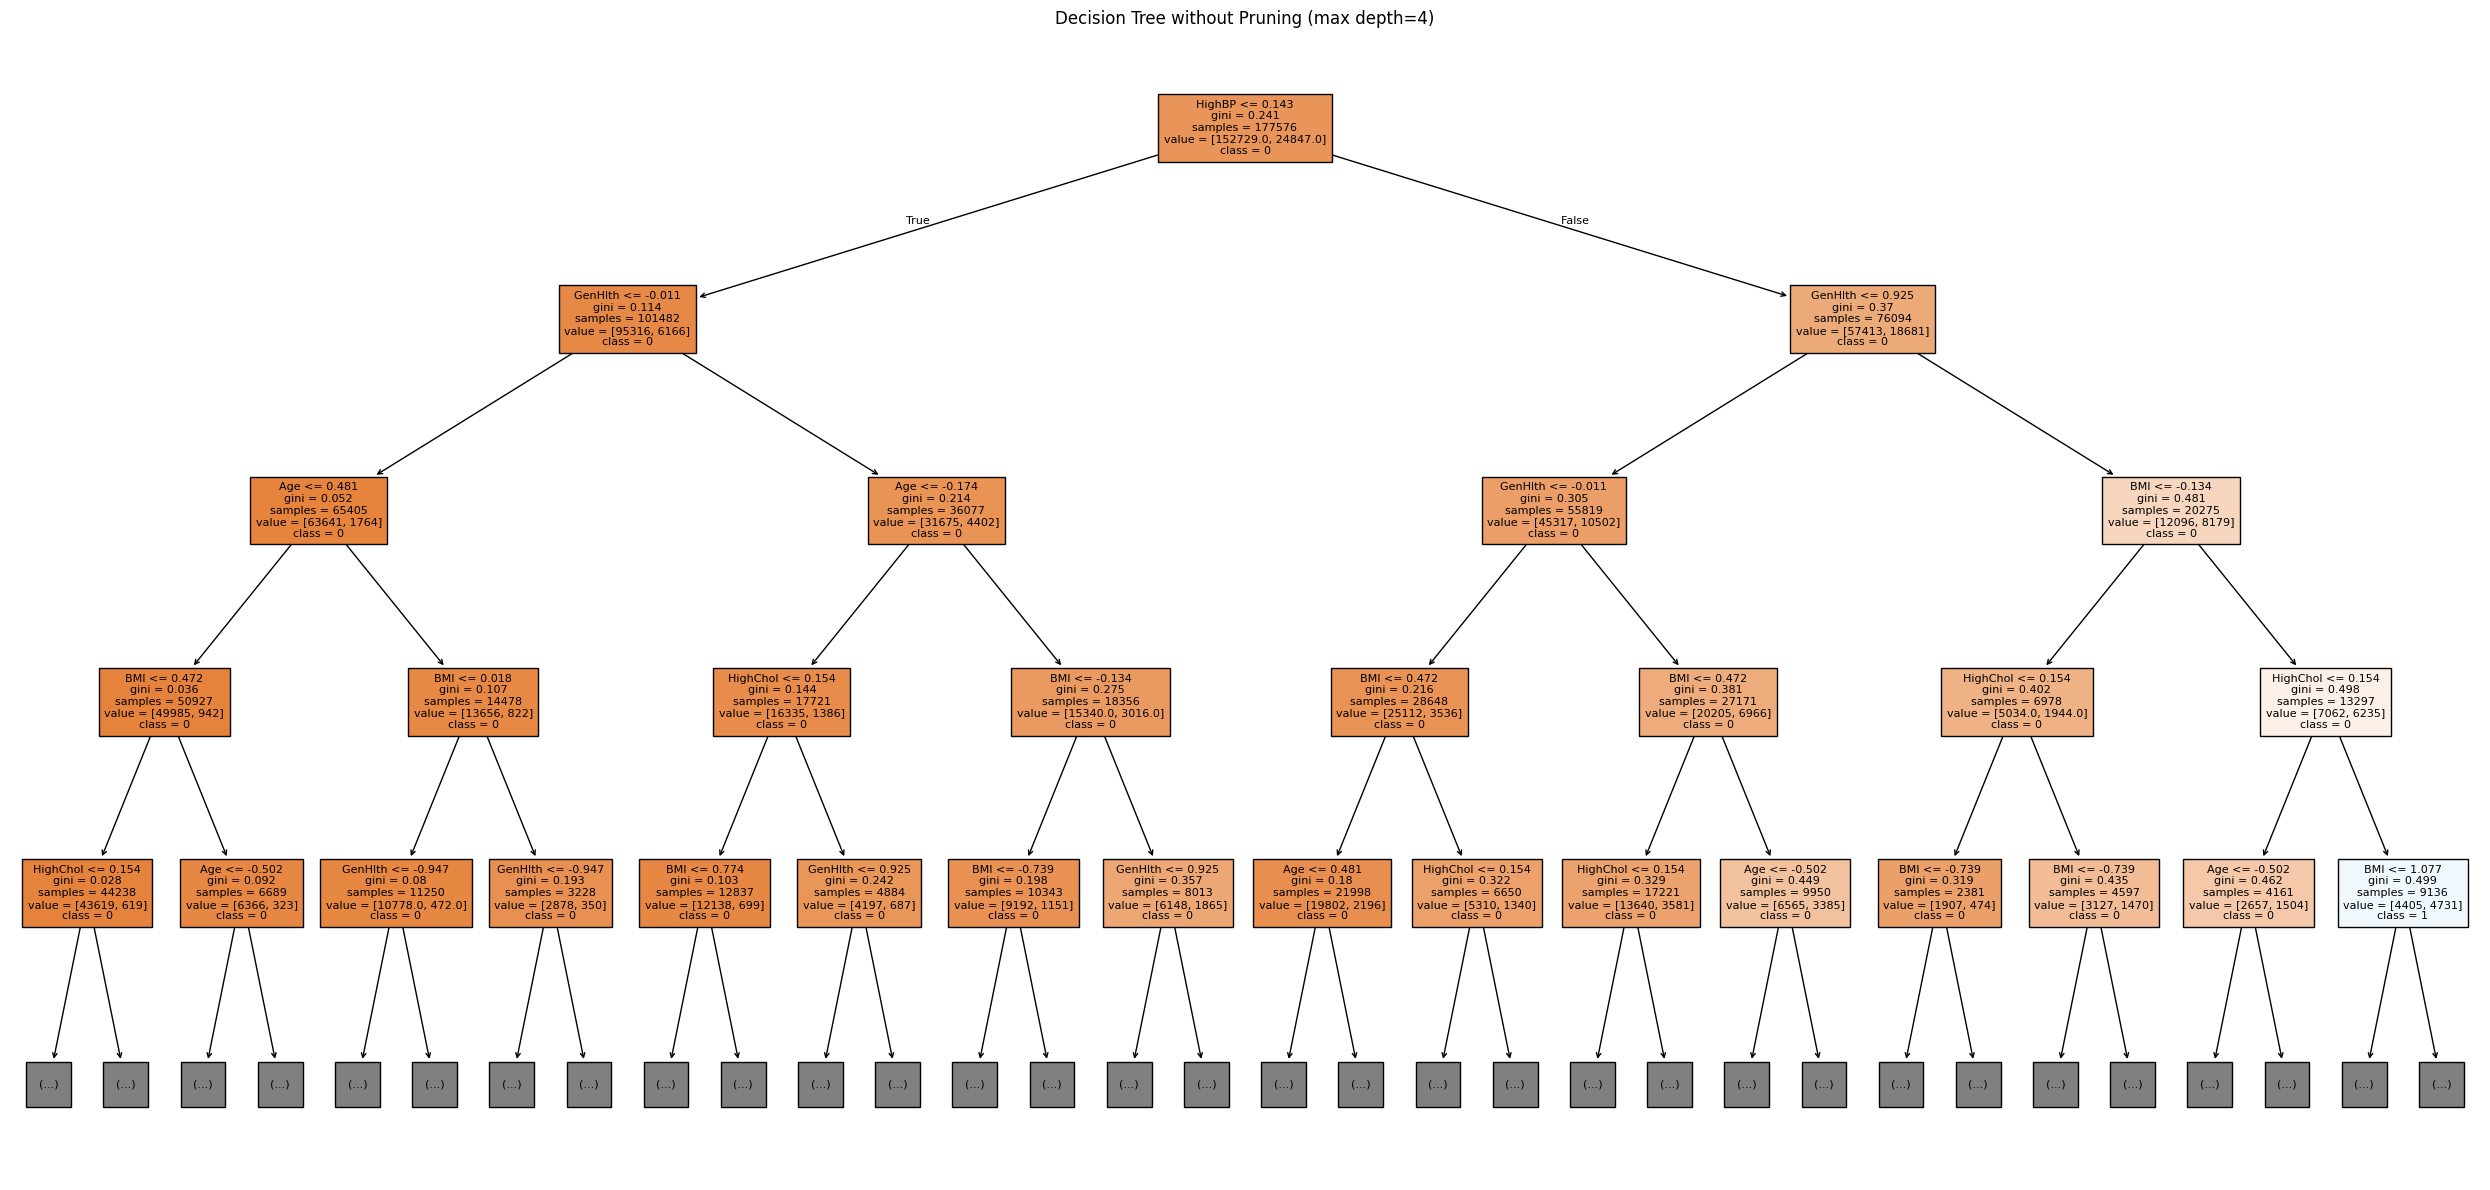

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt_no_pruning = DecisionTreeClassifier(random_state=42)
dt_no_pruning.fit(X_train, y_train)

y_pred_no_prune = dt_no_pruning.predict(X_test)

show_tree_metrics(dt_no_pruning, y_test, y_pred_no_prune)
print_tree(dt_no_pruning, 4, "Decision Tree without Pruning (max depth=4)")

Random Forests

Accuracy: 0.8572


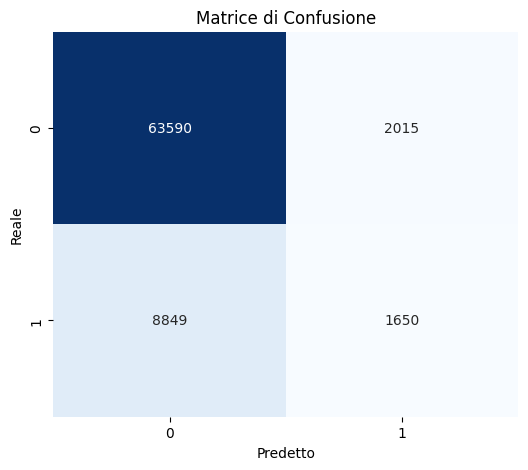


              precision    recall  f1-score   support

           0       0.88      0.97      0.92     65605
           1       0.45      0.16      0.23     10499

    accuracy                           0.86     76104
   macro avg       0.66      0.56      0.58     76104
weighted avg       0.82      0.86      0.83     76104



In [37]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

show_tree_metrics(model, y_test, y_pred)

### With Pruning

Accuracy: 0.8654
Profondità albero: 8
Numero di foglie: 33


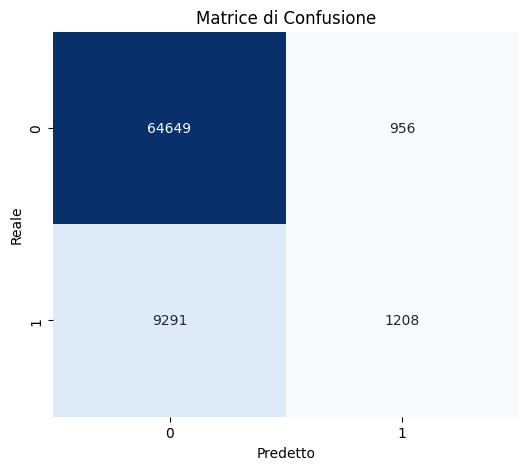


              precision    recall  f1-score   support

           0       0.87      0.99      0.93     65605
           1       0.56      0.12      0.19     10499

    accuracy                           0.87     76104
   macro avg       0.72      0.55      0.56     76104
weighted avg       0.83      0.87      0.83     76104



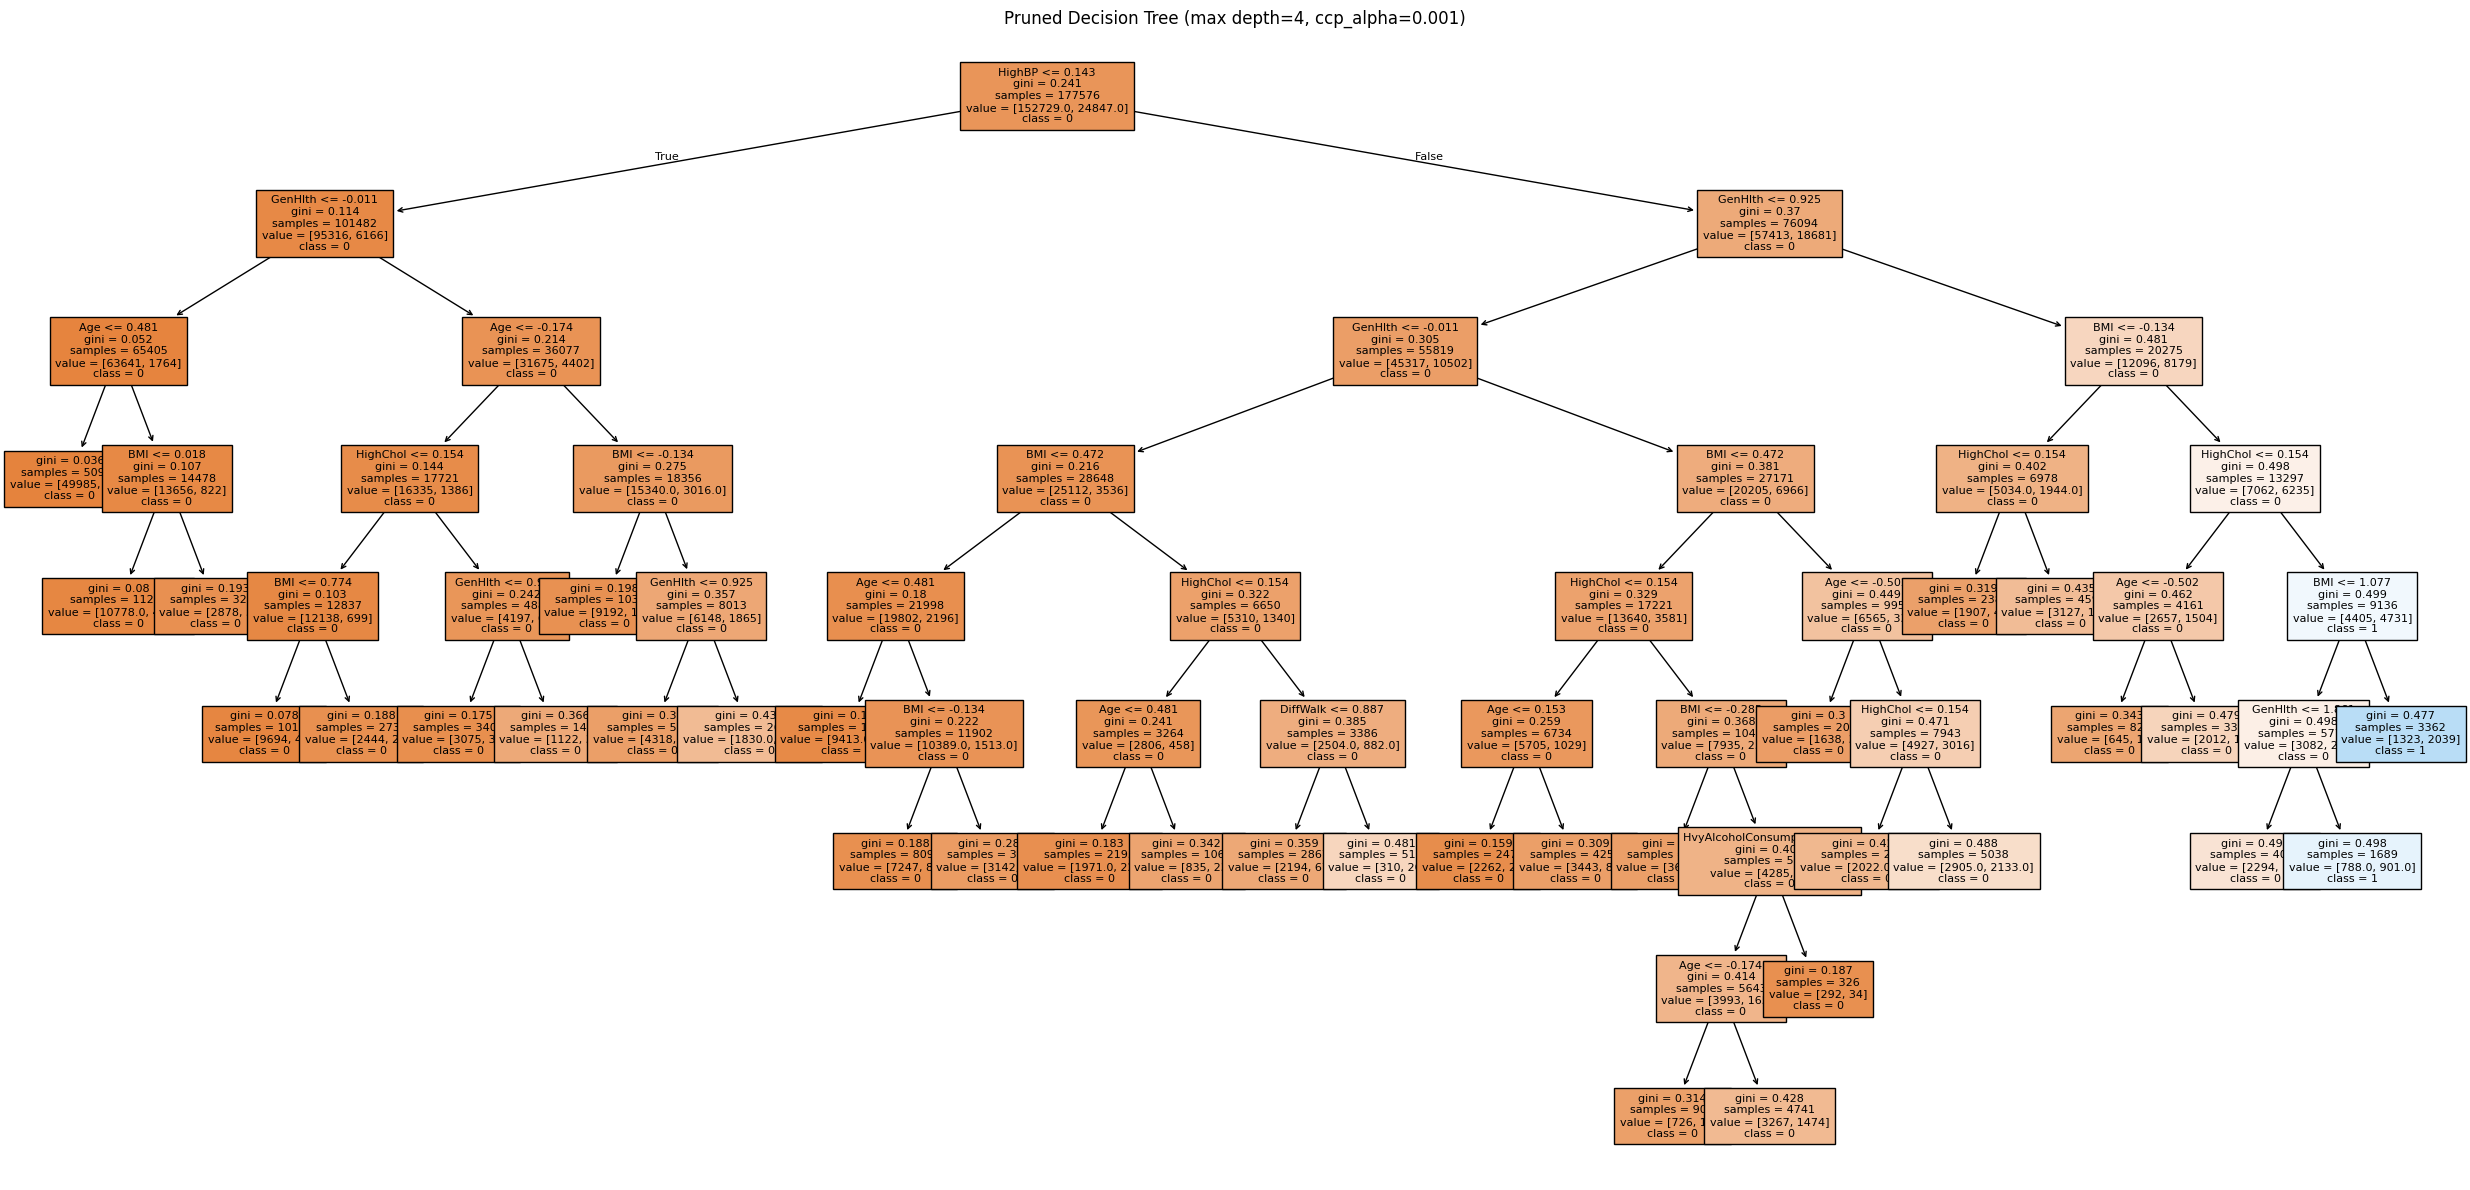

In [38]:
dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=0.0001)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)
show_tree_metrics(dt_pruned, y_test, y_pred_pruned)
print_tree(dt_pruned, dt_pruned.get_depth(), "Pruned Decision Tree (max depth=4, ccp_alpha=0.001)")

## PCA

### No Pruning

Accuracy: 0.8008
Profondità albero: 50
Numero di foglie: 19037


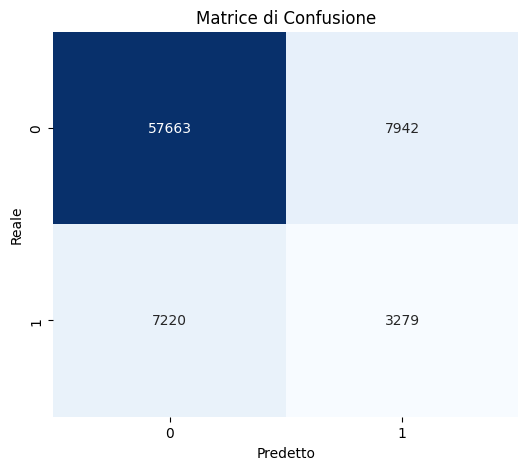


              precision    recall  f1-score   support

           0       0.89      0.88      0.88     65605
           1       0.29      0.31      0.30     10499

    accuracy                           0.80     76104
   macro avg       0.59      0.60      0.59     76104
weighted avg       0.81      0.80      0.80     76104



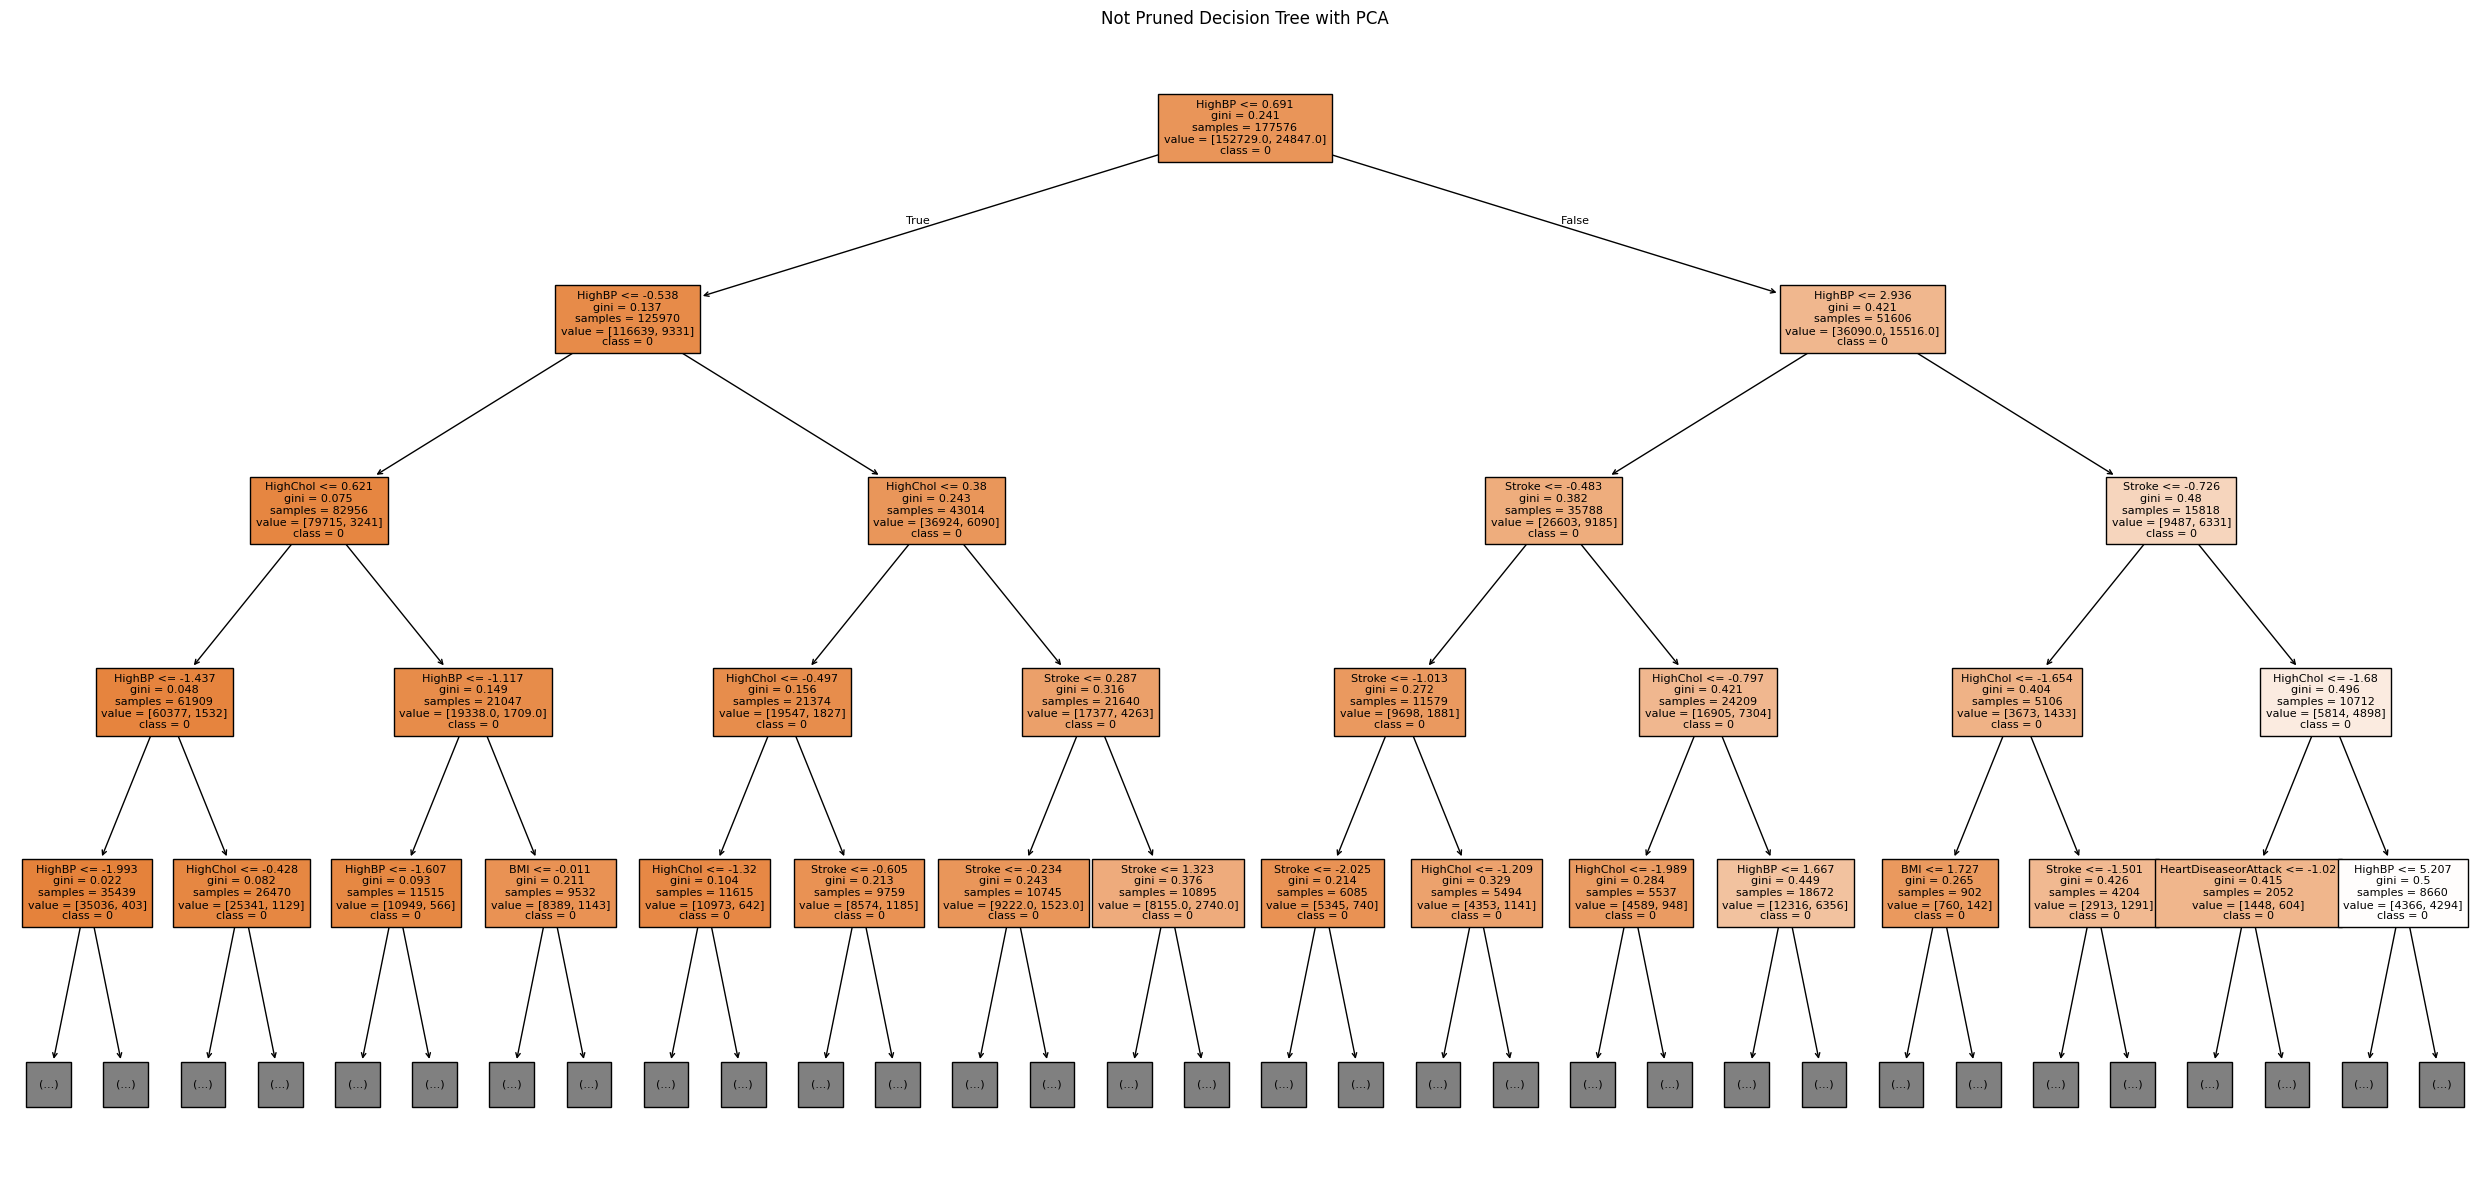

In [39]:
dt_pca_no_pruned = DecisionTreeClassifier(random_state=42)
dt_pca_no_pruned.fit(X_train_pca, y_train_pca)

y_pred_no_pruned = dt_pca_no_pruned.predict(X_test_pca)
show_tree_metrics(dt_pca_no_pruned, y_test_pca, y_pred_no_pruned)
print_tree(dt_pca_no_pruned, 4, "Not Pruned Decision Tree with PCA")

### With Pruning

Accuracy: 0.8629
Profondità albero: 7
Numero di foglie: 36


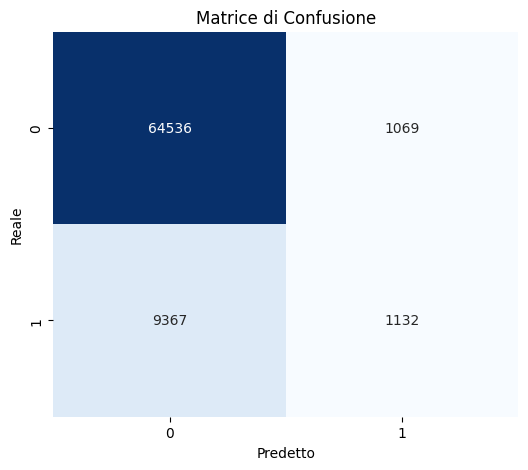


              precision    recall  f1-score   support

           0       0.87      0.98      0.93     65605
           1       0.51      0.11      0.18     10499

    accuracy                           0.86     76104
   macro avg       0.69      0.55      0.55     76104
weighted avg       0.82      0.86      0.82     76104



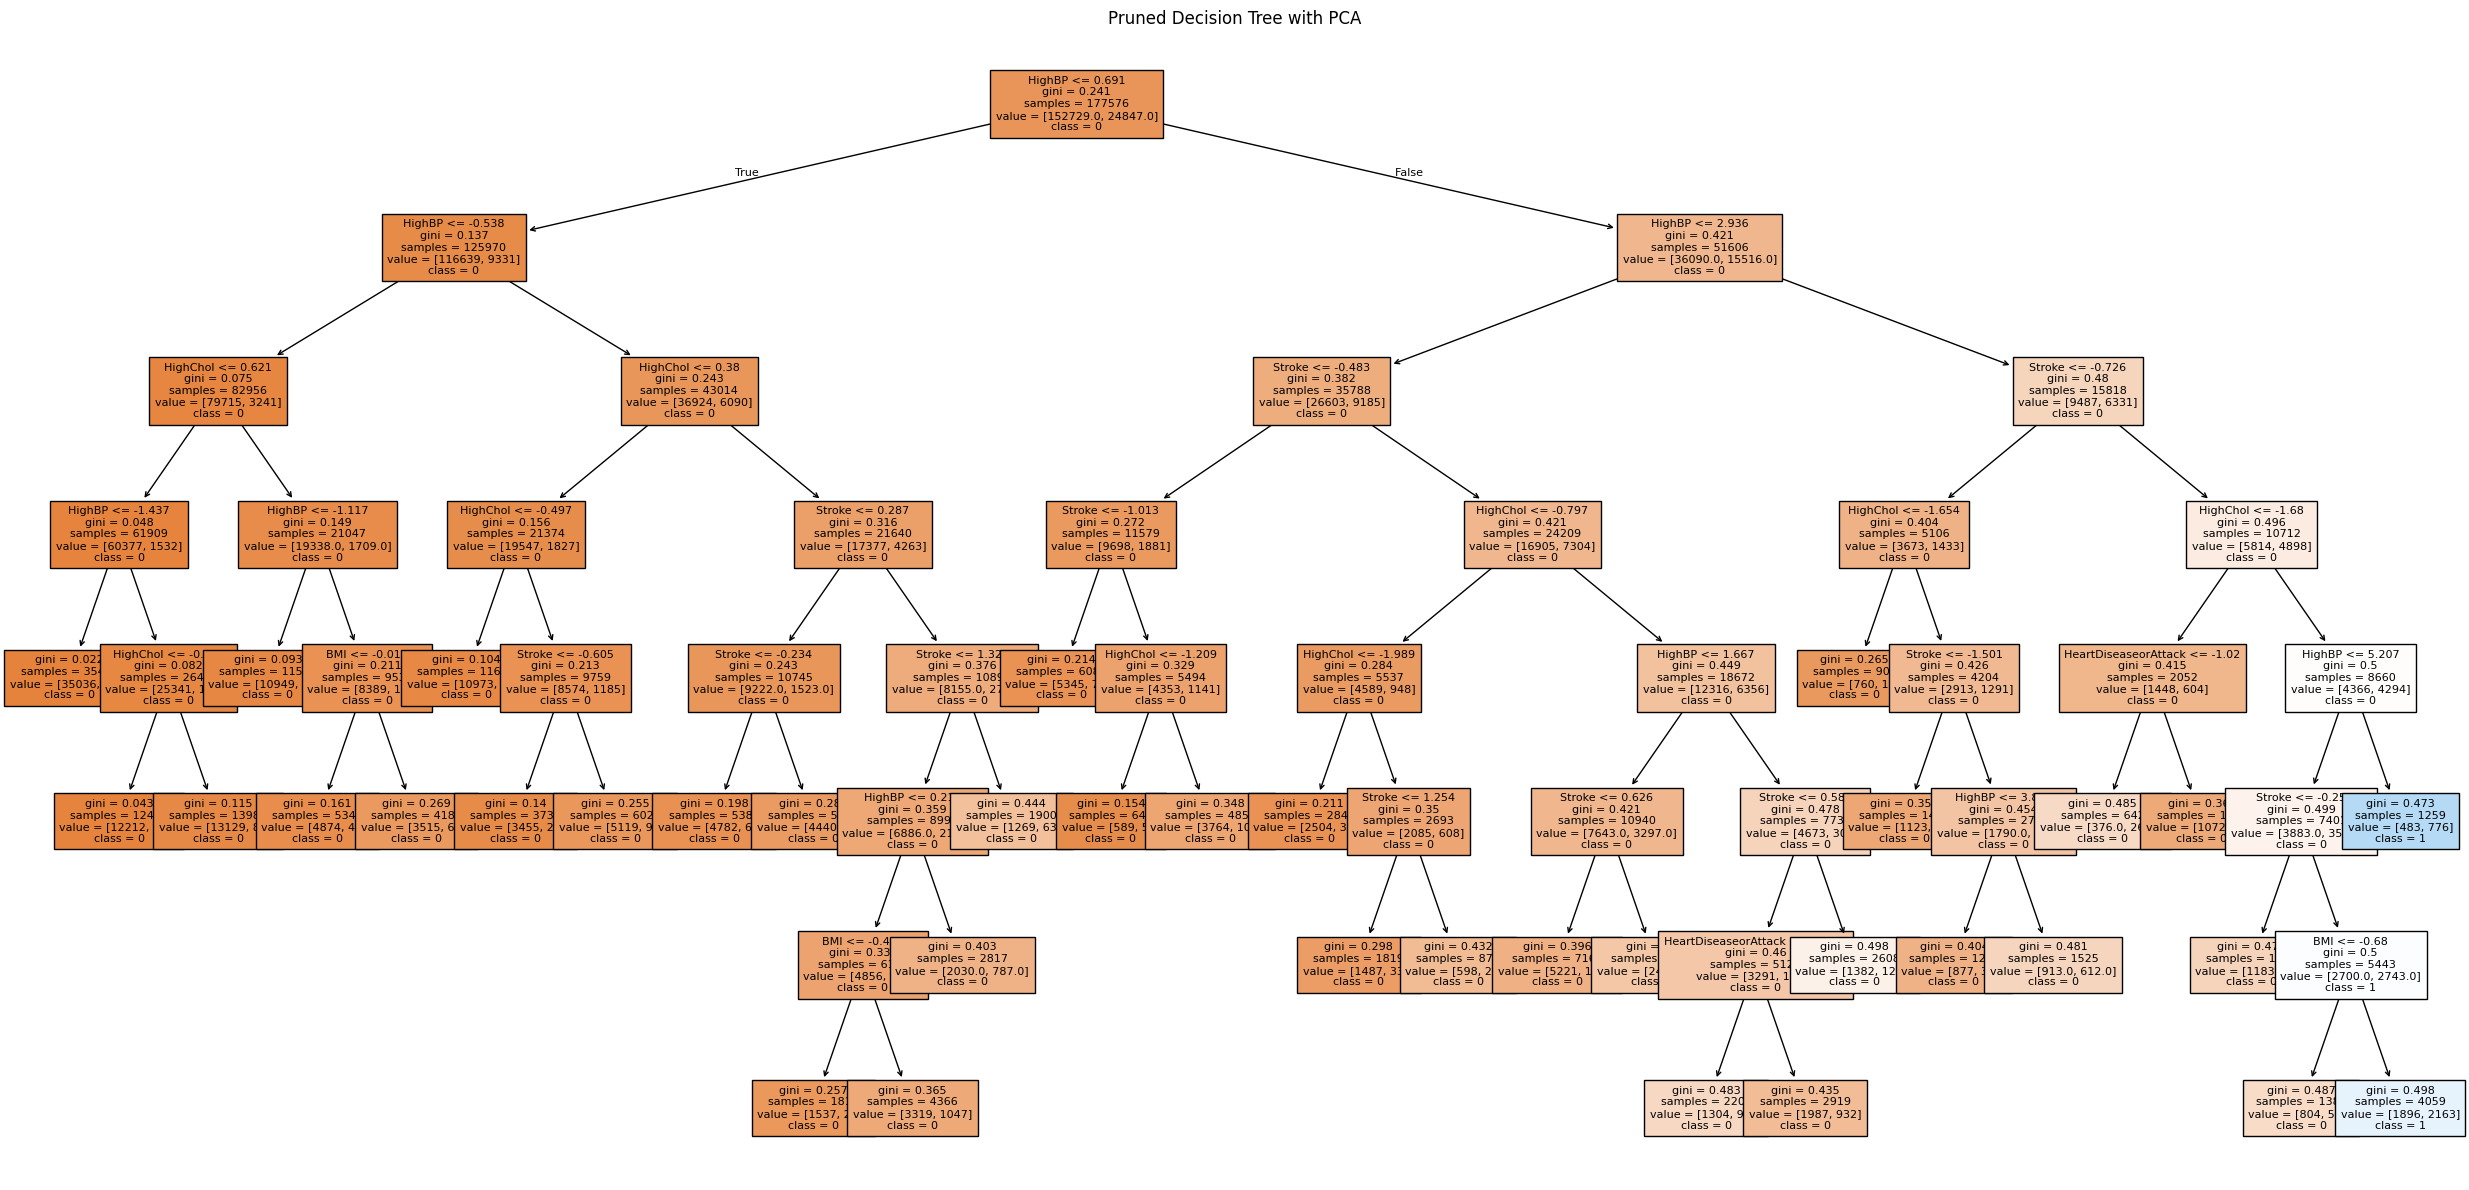

In [40]:
dt_pca_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=0.0001)
dt_pca_pruned.fit(X_train_pca, y_train_pca)

y_pred_pruned = dt_pca_pruned.predict(X_test_pca)
show_tree_metrics(dt_pca_pruned, y_test_pca, y_pred_pruned)
print_tree(dt_pca_pruned, dt_pca_pruned.get_depth(), "Pruned Decision Tree with PCA")

# Support Vector Machines

In [41]:
def show_metrics_svm(model, y_test, y_pred):
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    # Opzionale: Se il modello è un SVC (non LinearSVC), possiamo stampare i vettori di supporto
    if hasattr(model, 'n_support_'):
        print(f"Numero di vettori di supporto: {sum(model.n_support_)}")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    plt.title("Matrice di Confusione (SVM)")
    plt.show()

    print("\n" + classification_report(y_test, y_pred))

## Linear Kernel

Accuracy: 0.8620
Numero di vettori di supporto: 55437

              precision    recall  f1-score   support

           0       0.86      1.00      0.93     65605
           1       0.00      0.00      0.00     10499

    accuracy                           0.86     76104
   macro avg       0.43      0.50      0.46     76104
weighted avg       0.74      0.86      0.80     76104



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


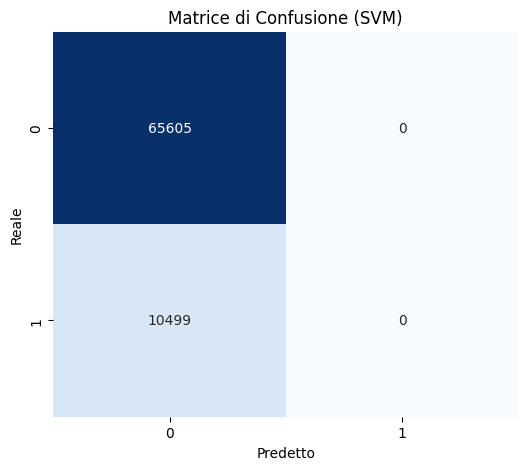

In [42]:
from sklearn.svm import LinearSVC, SVC

svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

show_metrics_svm(svm_linear, y_test, y_pred_linear)


## Kernel RBF

Accuracy: 0.8648
Numero di vettori di supporto: 3566

              precision    recall  f1-score   support

           0       0.87      0.99      0.93     65605
           1       0.58      0.07      0.13     10499

    accuracy                           0.86     76104
   macro avg       0.73      0.53      0.53     76104
weighted avg       0.83      0.86      0.82     76104



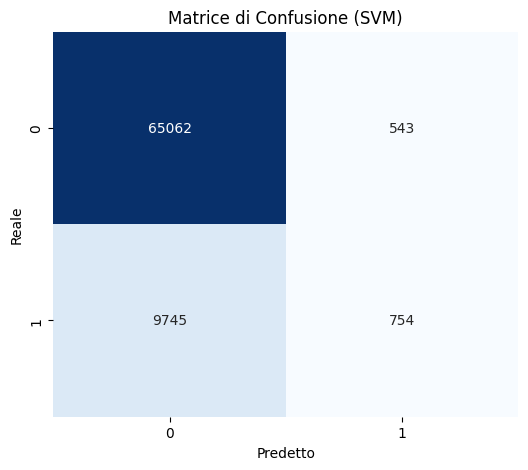

In [43]:
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

svm_rbf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_rbf.fit(X_train_small, y_train_small)
y_pred_rbf = svm_rbf.predict(X_test)

show_metrics_svm(svm_rbf, y_test, y_pred_rbf)